In [1]:
%pip install phik optuna pytorch_tabnet -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import functools
import os
import random
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import phik
import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import torch
from pytorch_tabnet.tab_model import TabNetClassifier

In [3]:
warnings.filterwarnings("ignore", message="Best weights from best epoch are automatically used!")

In [4]:
def seed_everything(seed=42):
    torch.manual_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything()

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [6]:
df = pd.read_csv('/kaggle/input/datasets/toperok/op-1-phishing-sites/public_data.csv')
display(df.head(10))
display(df.describe())
display(df.info())

,Row_id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,0,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,2,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,3,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,4,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
5,5,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1
6,6,1,0,-1,1,1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,1,0,-1,-1
7,7,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,0,-1,1,0,1,-1
8,8,1,0,-1,1,1,-1,1,1,-1,...,1,1,1,-1,1,1,1,0,1,1
9,9,1,1,-1,1,1,-1,-1,1,-1,...,1,1,1,-1,0,-1,1,0,1,-1


,Row_id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,9949.000000,9949.000000,9949.000000,9949.000000,9949.000000,9949.000000,9949.00000,9949.000000,9949.000000,9949.000000,...,9949.000000,9949.000000,9949.000000,9949.000000,9949.000000,9949.000000,9949.000000,9949.000000,9949.000000,9949.000000
mean,4974.000000,0.357724,-0.634637,0.740074,0.710725,0.741080,-0.73525,0.036386,0.254397,-0.339833,...,0.613428,0.816263,-0.003116,0.333601,0.291085,-0.463464,0.723992,0.343452,0.703488,0.112474
std,2872.173248,0.933874,0.764940,0.672559,0.703506,0.671451,0.67783,0.812475,0.911059,0.940533,...,0.789790,0.577710,1.000045,0.942762,0.833254,0.886160,0.689843,0.570116,0.710743,0.993705
min,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2487.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.00000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,4974.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.00000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,-1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,7461.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.00000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,9948.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9949 entries, 0 to 9948
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Row_id                       9949 non-null   int64
 1   having_IP_Address            9949 non-null   int64
 2   URL_Length                   9949 non-null   int64
 3   Shortining_Service           9949 non-null   int64
 4   having_At_Symbol             9949 non-null   int64
 5   double_slash_redirecting     9949 non-null   int64
 6   Prefix_Suffix                9949 non-null   int64
 7   having_Sub_Domain            9949 non-null   int64
 8   SSLfinal_State               9949 non-null   int64
 9   Domain_registeration_length  9949 non-null   int64
 10  Favicon                      9949 non-null   int64
 11  port                         9949 non-null   int64
 12  HTTPS_token                  9949 non-null   int64
 13  Request_URL                  9949 non-null   int

None

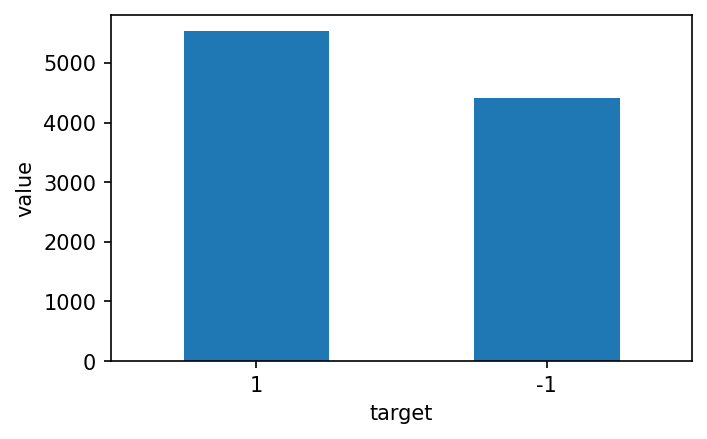

In [7]:
count_val = df['Result'].value_counts()

plt.figure(figsize=(5,3), dpi=150)

ax = count_val.plot(
    kind='bar',
    x='Result',
    xlabel='target',
    ylabel='value',
    rot=0,
)

plt.show()

In [8]:
df_eda = df.copy()

df_eda = df_eda.drop('Row_id', axis=1)

In [9]:
df_eda.isnull().sum()

having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

In [10]:
print('Row duplicate:', df_eda.duplicated().sum())

df_eda = df_eda.drop_duplicates()

Row duplicate: 4589


In [11]:
def select_unique(df):
  df_data = df.astype(str)
  data = []

  for col in df.columns:
    data.append({
        'Feature': col,
        'Unique': ', '.join(df_data[col].unique()),
        'Amount': df_data[col].nunique()
    })

  return pd.DataFrame(data)

select_unique(df_eda)

,Feature,Unique,Amount
0,having_IP_Address,"-1, 1",2
1,URL_Length,"1, 0, -1",3
2,Shortining_Service,"1, -1",2
3,having_At_Symbol,"1, -1",2
4,double_slash_redirecting,"-1, 1",2
5,Prefix_Suffix,"-1, 1",2
6,having_Sub_Domain,"-1, 0, 1",3
7,SSLfinal_State,"-1, 1, 0",3
8,Domain_registeration_length,"-1, 1",2
9,Favicon,"1, -1",2


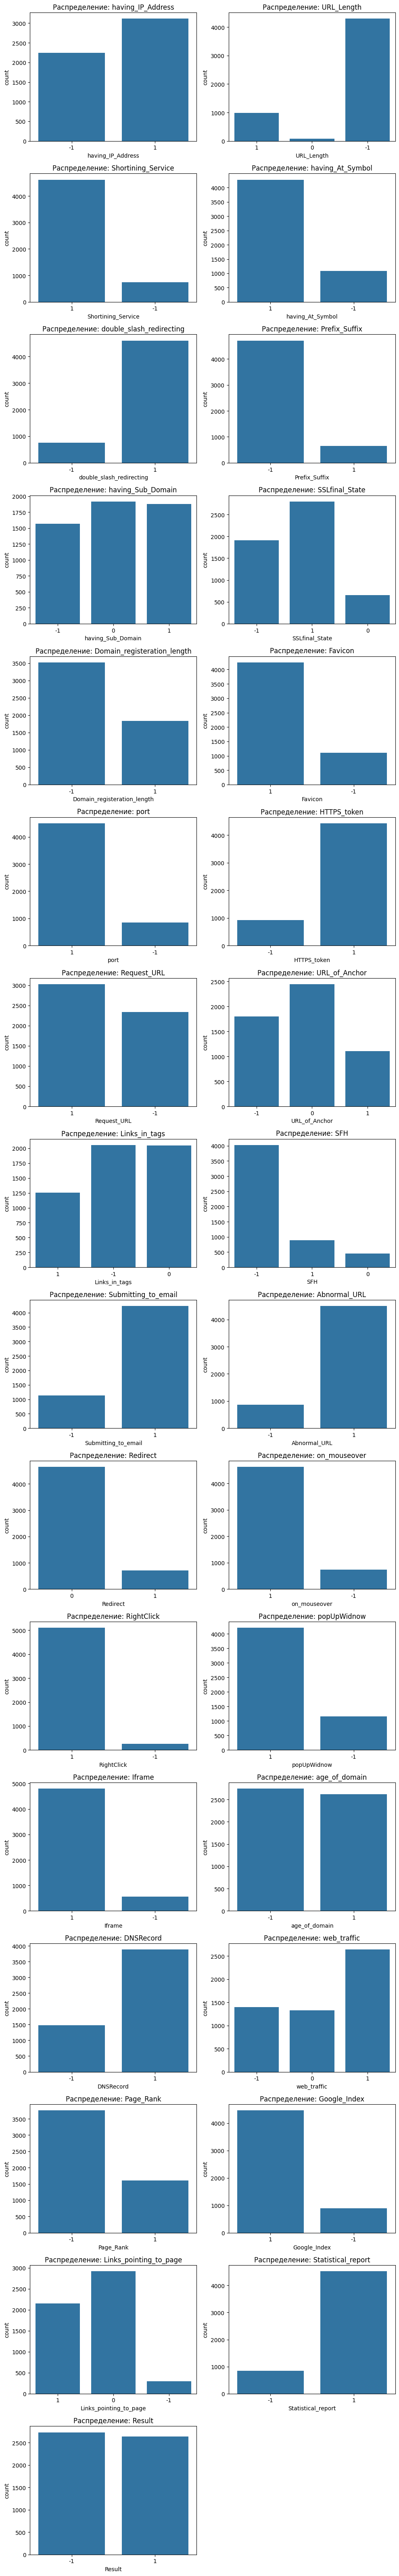

In [12]:
def count_plots(df):
  cols = df.columns
  n_cols = 2
  n_rows = (len(cols) + 1) // 2

  fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, n_rows * 4))
  axes = axes.flatten()

  for i, col_name in enumerate(cols):
    sns.countplot(x=df[col_name].astype(str), ax=axes[i])
    axes[i].set_title(f'Распределение: {col_name}')

  if len(cols) % 2 != 0:
    fig.delaxes(axes[-1])

  plt.tight_layout()
  plt.show()
  plt.close()

count_plots(df_eda)

interval columns not set, guessing: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


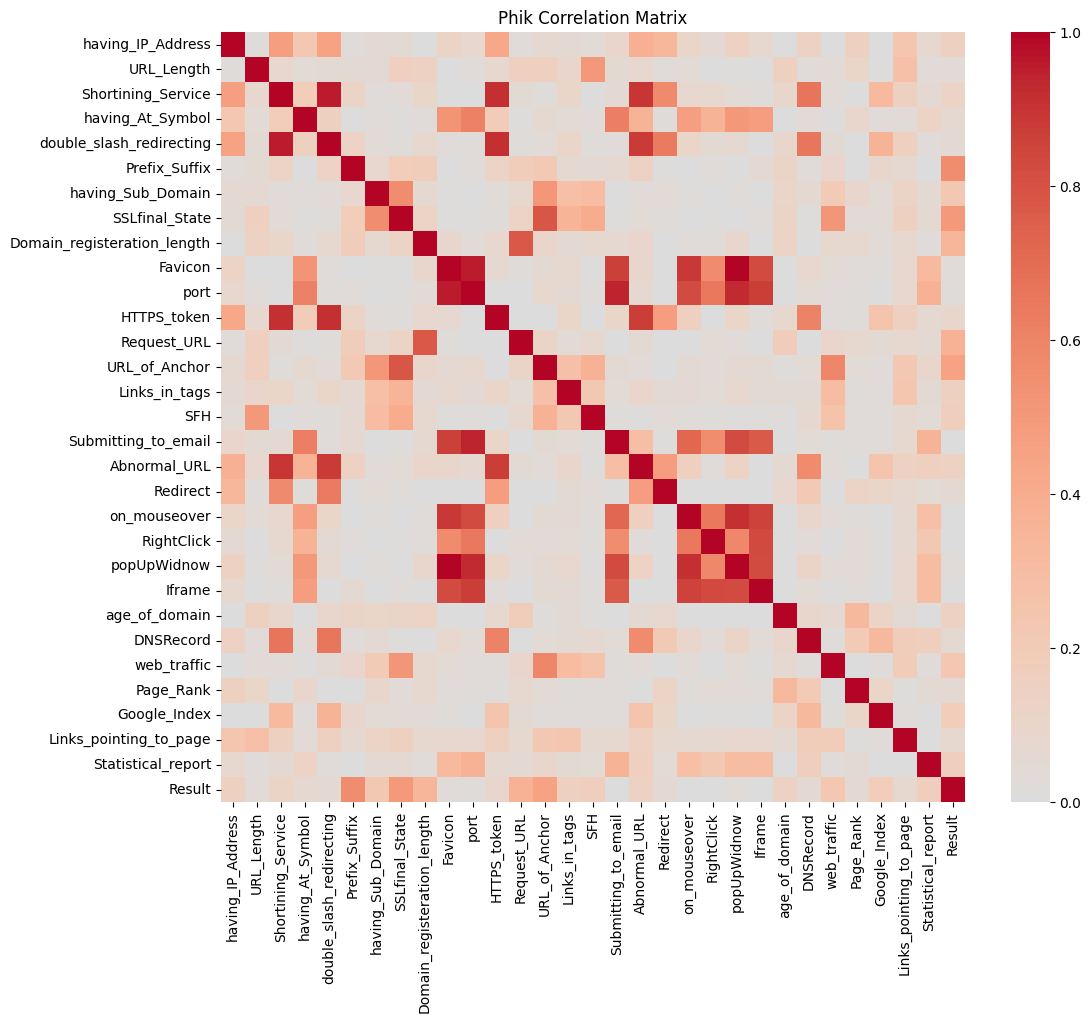

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
having_IP_Address,1.000000,0.021362,0.474704,0.229752,0.460284,0.024719,0.060514,0.048007,0.000000,0.118398,...,0.139781,0.076462,0.000000,0.144004,0.000000,0.152361,0.000000,0.234614,0.073060,0.149352
URL_Length,0.021362,1.000000,0.080287,0.042769,0.052780,0.050928,0.057063,0.158433,0.141656,0.000000,...,0.009690,0.000000,0.153070,0.025109,0.036885,0.102706,0.000000,0.277112,0.026885,0.036976
Shortining_Service,0.474704,0.080287,1.000000,0.181612,0.956858,0.118348,0.030088,0.038994,0.101969,0.000000,...,0.046172,0.022768,0.088498,0.668975,0.038482,0.000000,0.319779,0.155919,0.059342,0.121327
having_At_Symbol,0.229752,0.042769,0.181612,1.000000,0.156053,0.002560,0.027553,0.015390,0.025610,0.529283,...,0.504314,0.481252,0.000000,0.037543,0.012724,0.092556,0.031221,0.032050,0.125726,0.063909
double_slash_redirecting,0.460284,0.052780,0.956858,0.156053,1.000000,0.126370,0.032759,0.022047,0.074745,0.027130,...,0.065972,0.000000,0.090674,0.661381,0.048659,0.006940,0.366060,0.154273,0.027389,0.060999
Prefix_Suffix,0.024719,0.050928,0.118348,0.002560,0.126370,1.000000,0.082389,0.184312,0.172768,0.000000,...,0.000000,0.060978,0.114763,0.028202,0.097781,0.000000,0.091361,0.064303,0.000000,0.558912
having_Sub_Domain,0.060514,0.057063,0.030088,0.027553,0.032759,0.082389,1.000000,0.561689,0.065310,0.011692,...,0.015945,0.000000,0.107316,0.056851,0.197419,0.086396,0.044071,0.119289,0.058724,0.225656
SSLfinal_State,0.048007,0.158433,0.038994,0.015390,0.022047,0.184312,0.561689,1.000000,0.117608,0.010858,...,0.007563,0.024046,0.114650,0.011459,0.523118,0.038236,0.043399,0.150314,0.057000,0.500000
Domain_registeration_length,0.000000,0.141656,0.101969,0.025610,0.074745,0.172768,0.065310,0.117608,1.000000,0.091831,...,0.087584,0.000000,0.120565,0.000000,0.074363,0.076277,0.038114,0.075314,0.029113,0.348981
Favicon,0.118398,0.000000,0.000000,0.529283,0.027130,0.000000,0.011692,0.010858,0.091831,1.000000,...,0.994478,0.821684,0.000000,0.085436,0.045184,0.025818,0.022862,0.085460,0.320094,0.024767


In [13]:
def phik_df(df):
  phik_matrix = df.phik_matrix(njobs=1)

  plt.figure(figsize=(12, 10))
  sns.heatmap(phik_matrix,
              fmt=".2f",
              cmap='coolwarm',
              center=0)

  plt.title("Phik Correlation Matrix")
  plt.show()

  display(phik_matrix)

phik_df(df_eda)

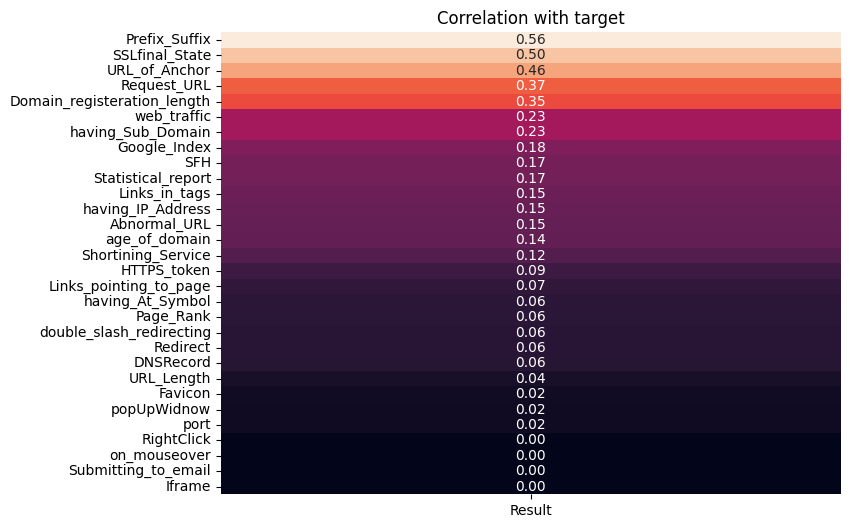

In [14]:
def create_heatmap(df):
    plt.figure(figsize=(8,6))
    ax = plt.gca()

    sns.heatmap(
        df,
        annot=True,
        fmt='.2f',
        cbar=False,
        ax=ax
    )

    ax.set_title('Correlation with target')

    plt.show()
    plt.close()



df_eda1 = df_eda.copy().astype(str)

corr_mat = df_eda1.phik_matrix(njobs=6)
target_correlation = corr_mat[corr_mat.index != 'Result'][['Result']].sort_values(by='Result', ascending=False)


create_heatmap(target_correlation)

In [15]:
df_eda = df_eda.drop(['Iframe', 'Submitting_to_email', 'on_mouseover', 'RightClick'], axis=1)

In [16]:
display(df_eda.head(10))
display(df_eda.describe())
display(df_eda.info())

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,Redirect,popUpWidnow,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,0,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,0,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,0,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,0,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,0,-1,-1,-1,0,-1,1,1,1,1
5,-1,0,-1,1,-1,-1,1,1,-1,1,...,0,1,1,1,1,-1,1,-1,-1,1
6,1,0,-1,1,1,-1,-1,-1,1,1,...,0,1,1,-1,-1,-1,1,0,-1,-1
7,1,0,1,1,1,-1,-1,-1,1,1,...,0,1,-1,-1,0,-1,1,0,1,-1
8,1,0,-1,1,1,-1,1,1,-1,1,...,0,1,1,-1,1,1,1,0,1,1
9,1,1,-1,1,1,-1,-1,1,-1,1,...,0,1,1,-1,0,-1,1,0,1,-1


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,Redirect,popUpWidnow,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,5360.000000,5360.000000,5360.000000,5360.000000,5360.00000,5360.000000,5360.000000,5360.000000,5360.000000,5360.000000,...,5360.000000,5360.000000,5360.000000,5360.000000,5360.000000,5360.000000,5360.000000,5360.000000,5360.000000,5360.000000
mean,0.161567,-0.618097,0.722761,0.597388,0.71791,-0.757463,0.058396,0.166418,-0.313806,0.585075,...,0.132836,0.569776,-0.023507,0.449627,0.231903,-0.401493,0.666045,0.347388,0.686567,-0.018284
std,0.986954,0.776022,0.691162,0.802027,0.69620,0.652939,0.799412,0.922198,0.949576,0.811055,...,0.339429,0.821877,0.999817,0.893300,0.836152,0.915948,0.745981,0.579420,0.727134,0.999926
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.00000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.00000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,0.000000,1.000000,-1.000000,1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.00000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
Index: 5360 entries, 0 to 9948
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            5360 non-null   int64
 1   URL_Length                   5360 non-null   int64
 2   Shortining_Service           5360 non-null   int64
 3   having_At_Symbol             5360 non-null   int64
 4   double_slash_redirecting     5360 non-null   int64
 5   Prefix_Suffix                5360 non-null   int64
 6   having_Sub_Domain            5360 non-null   int64
 7   SSLfinal_State               5360 non-null   int64
 8   Domain_registeration_length  5360 non-null   int64
 9   Favicon                      5360 non-null   int64
 10  port                         5360 non-null   int64
 11  HTTPS_token                  5360 non-null   int64
 12  Request_URL                  5360 non-null   int64
 13  URL_of_Anchor                5360 non-null   int64
 1

None

In [17]:
features = [col for col in df_eda.columns if col != 'Result']

df_encoded = df.copy()
encoders = {}

for col in features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoders[col] = le

le_target = LabelEncoder()
df_encoded['Result'] = le_target.fit_transform(df['Result'])

cat_idxs = [i for i, f in enumerate(features)]
cat_dims = [df_encoded[f].nunique() for f in features]


In [18]:
class Config:
    MAX_EPOCHS = 200
    BATCH_SIZE = 256
    VIRTUAL_BATCH_SIZE = 32
    N_TRIALS = 30
    PATIENCE = 30

    DEFAULTS = {
        "cat_idxs": cat_idxs,
        "cat_dims": cat_dims,
        "cat_emb_dim": 2,
        "n_d": 8,
        "n_a": 8,
        "n_steps": 3,
        "gamma": 1.3,
        "lambda_sparse": 1e-3,
        "optimizer_params": dict(lr=2e-2),
        "mask_type": "entmax",
    }
 

In [19]:
X = df_encoded[features].values
y = df_encoded['Result'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

In [20]:
def objective(trial):

    n_common = trial.suggest_int("n_common", 16, 48, step=8)
    
    params = {
        "n_d": n_common,
        "n_a": n_common,
        "n_steps": trial.suggest_int("n_steps", 3, 6),
        "gamma": trial.suggest_float("gamma", 1.0, 1.5),
        "lambda_sparse": trial.suggest_float("lambda_sparse", 1e-4, 1e-2, log=True),
        "cat_emb_dim": trial.suggest_int("cat_emb_dim", 1, 3),
        "mask_type": trial.suggest_categorical("mask_type", ["entmax"]),
        "optimizer_params": dict(lr=trial.suggest_float("lr", 0.007, 0.03, log=True))
    }

    clf = TabNetClassifier(
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        device_name=device,
        **params,
        verbose=0
    )


    clf.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['accuracy'],
    max_epochs=Config.MAX_EPOCHS,
    patience=Config.PATIENCE,
    batch_size=Config.BATCH_SIZE,
    virtual_batch_size=Config.VIRTUAL_BATCH_SIZE
)

    return clf.best_cost

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=Config.N_TRIALS)

print(f"Лучшие параметры: {study.best_params}")

[I 2026-04-29 10:37:25,495] A new study created in memory with name: no-name-20762178-0742-454f-a4bc-311b93400224



Early stopping occurred at epoch 146 with best_epoch = 116 and best_val_accuracy = 0.97048


[I 2026-04-29 10:40:28,252] Trial 0 finished with value: 0.9704773869346733 and parameters: {'n_common': 40, 'n_steps': 4, 'gamma': 1.307423697216786, 'lambda_sparse': 0.0002959650449821673, 'cat_emb_dim': 2, 'mask_type': 'entmax', 'lr': 0.007134580231436985}. Best is trial 0 with value: 0.9704773869346733.



Early stopping occurred at epoch 131 with best_epoch = 101 and best_val_accuracy = 0.96482


[I 2026-04-29 10:42:38,354] Trial 1 finished with value: 0.964824120603015 and parameters: {'n_common': 16, 'n_steps': 3, 'gamma': 1.46264292296915, 'lambda_sparse': 0.00143405631616334, 'cat_emb_dim': 1, 'mask_type': 'entmax', 'lr': 0.010357421128499253}. Best is trial 0 with value: 0.9704773869346733.


...


Early stopping occurred at epoch 115 with best_epoch = 85 and best_val_accuracy = 0.96294


[I 2026-04-29 11:36:43,112] Trial 19 finished with value: 0.9629396984924623 and parameters: {'n_common': 40, 'n_steps': 6, 'gamma': 1.1141511062159002, 'lambda_sparse': 0.008169153096379866, 'cat_emb_dim': 3, 'mask_type': 'entmax', 'lr': 0.012254827689450434}. Best is trial 6 with value: 0.9717336683417085.



Early stopping occurred at epoch 144 with best_epoch = 114 and best_val_accuracy = 0.96671


[I 2026-04-29 11:41:12,963] Trial 20 finished with value: 0.9667085427135679 and parameters: {'n_common': 32, 'n_steps': 6, 'gamma': 1.245115547302223, 'lambda_sparse': 0.004442962431210079, 'cat_emb_dim': 3, 'mask_type': 'entmax', 'lr': 0.009295354115577874}. Best is trial 6 with value: 0.9717336683417085.
[W 2026-04-29 11:43:41,393] Trial 21 failed with parameters: {'n_common': 40, 'n_steps': 5, 'gamma': 1.30041970954527, 'lambda_sparse': 0.0009274478448570853, 'cat_emb_dim': 2, 'mask_type': 'entmax', 'lr': 0.010896129336323846} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_511/4222769312.py", line 25, in objective
    clf.fit(
  File "/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py", line 262, in fit
    self._predict_epoch(eval_

KeyboardInterrupt: 

Модель вышла на плато, смысла в дальнейшем оубчении с этими параметрами не имеет смысла, проведем тестирование на X_test, после чего зафиксируем результат.

In [21]:
print(f"Лучшая точность: {study.best_value}")
print(f"Лучшие параметры: {study.best_params}")

Лучшая точность: 0.9717336683417085
Лучшие параметры: {'n_common': 40, 'n_steps': 5, 'gamma': 1.227135940783975, 'lambda_sparse': 0.0008670548884873393, 'cat_emb_dim': 1, 'mask_type': 'entmax', 'lr': 0.009344991623499888}


In [22]:
df_results = study.trials_dataframe()
df_results.to_csv("optuna_results.csv", index=False)

In [23]:
joblib.dump(study, "tabnet_optimization.pkl")

['tabnet_optimization.pkl']

### Проверка модели на тестовой выборке

In [27]:
study_best = joblib.load("tabnet_optimization.pkl")

print(f"Загружен лучший скор: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

Загружен лучший скор: 0.9717
Лучшие параметры: {'n_common': 40, 'n_steps': 5, 'gamma': 1.227135940783975, 'lambda_sparse': 0.0008670548884873393, 'cat_emb_dim': 1, 'mask_type': 'entmax', 'lr': 0.009344991623499888}


In [29]:
%%time

best_params = study_best.best_params.copy()

tabnet_params = {
    "n_d": best_params["n_common"],
    "n_a": best_params["n_common"],
    "n_steps": best_params["n_steps"],
    "gamma": best_params["gamma"],
    "lambda_sparse": best_params["lambda_sparse"],
    "cat_emb_dim": best_params["cat_emb_dim"],
    "mask_type": best_params["mask_type"],
    "optimizer_params": dict(lr=best_params["lr"]),
    "device_name": 'cuda'
}

final_clf = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    **tabnet_params,
    verbose=0
)

X_final_train = np.concatenate([X_train, X_val])
y_final_train = np.concatenate([y_train, y_val])

print("Финальное обучение на Train + Val...")
final_clf.fit(
    X_train=X_final_train, y_train=y_final_train,
    max_epochs=200,
    patience=30,
    batch_size=256,
    virtual_batch_size=32
)

preds = final_clf.predict(X_test)


test_acc = accuracy_score(y_test, preds)

print(f"\nИТОГОВАЯ ТОЧНОСТЬ НА X_TEST: {test_acc:.4f}")
print("\nДетальный отчет:")
print(classification_report(y_test, preds))

Финальное обучение на Train + Val...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



ИТОГОВАЯ ТОЧНОСТЬ НА X_TEST: 0.9749

Детальный отчет:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       883
           1       0.98      0.98      0.98      1107

    accuracy                           0.97      1990
   macro avg       0.97      0.97      0.97      1990
weighted avg       0.97      0.97      0.97      1990



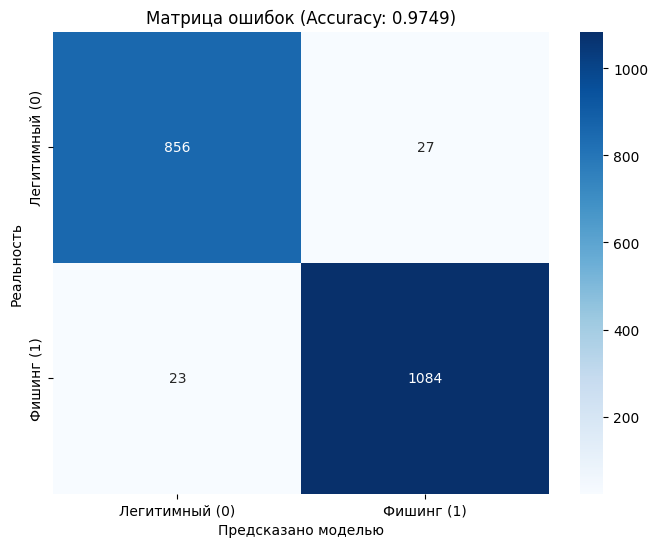

In [30]:
cm = confusion_matrix(y_test, preds)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Легитимный (0)', 'Фишинг (1)'], 
            yticklabels=['Легитимный (0)', 'Фишинг (1)'])

plt.title(f'Матрица ошибок (Accuracy: {test_acc:.4f})')
plt.ylabel('Реальность')
plt.xlabel('Предсказано моделью')
plt.show()